# Lecture 10: PyTorch Neural Network Architectures

How to "read" this lecture notebook
<details>
<summary>click to expand</summary>

As you go through this notebook (or any notebook for this class), you will encounter new concepts and python code that implements them -- just like you would see in a textbook. Of course, in a textbook, it's easy to read code and an explanation of what it does and think that you understand it.
<br />

### Learn by doing
But this notebook is different from a textbook because it allows you to not just read the code, but play with it. **You can and should try out changing the code that you see**. In fact, in many places throughout this reading notebook, you will be asked to write your own code to experiment with a concept that was just covered. This is a form of "active reading" and the idea behind it is that we really learn by **doing**. 
<br />

### Change everything
But don't feel limited to only change code when I prompt you. This notebook is your learning environment and your playground. I encourage you to try changing and running all the code throughout the notebook and even to **add your own notes and new code blocks**. Adding comments to code to explain what you are testing, experimenting with or trying to do is really helpful to understand what you were thinking when you revisit it later. 
<br />

### Make this notebook your own
Make this notebook your own. Write your questions and thoughts. At the end of every reading notebook, I will ask the same set of questions to try to elicit your questions, reaction and feedback. When we review the reading notebook in class, I encourage you to share!

</details>

## Learning Objectives

By the end of this lecture, you will be able to:
- Master PyTorch's `nn.Module` class for building neural networks
- Understand different layer types and activation functions
- Learn how to design and implement custom network architectures
- Debug common neural network issues
- Implement some regularization techniques

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🏗️
  </span>

  Last lecture we learned the fundamental building blocks of PyTorch: tensors, datasets, and training loops. Now it's time to design the actual neural networks we'll train. Think of this lecture as moving from knowing how bricks work to **designing entire buildings**. The architecture of your network — how many layers, what types, how they connect — is one of the most important decisions in deep learning.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

# 10.0 Code Preface

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Check PyTorch version and device
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.11.0
Using device: cpu


# 10.1 The `nn.Module` Class

<img alt="Vera gets transformed layer by layer by the evil computer in Superman 3" src="../images/L10_superman3_layers.png" width=900 style="display:block;">
<font size=2>Vera Webster gets transformed layer-by-layer by the evil computer in <i>Superman III (1983)</i>. Please don't make evil AI.</font>

In the last lecture, we used `nn.Sequential` to glue layers together quickly. That works for simple cases, but real-world networks often need more flexibility. The way to get that flexibility is by subclassing **`nn.Module`** — the base class for all neural network modules in PyTorch.

Every model you build in PyTorch extends `nn.Module`. This gives you:
- **Automatic parameter tracking** — PyTorch knows about every weight and bias
- **Device management** — move the whole model to GPU with one call
- **Training/eval mode** — toggle behaviors like dropout
- **Serialization** — save and load models easily

## The Two Methods You Must Implement

When you subclass `nn.Module`, you need to define two methods:

1. **`__init__(self)`** — Define the layers (the building materials)
2. **`forward(self, x)`** — Define how data flows through those layers (the blueprint)

Let's start with a simple example:

In [4]:
class SimpleNet(nn.Module):
    """A simple 2-layer neural network."""
    
    def __init__(self, input_size, hidden_size, output_size):  # notice the arguments here, which allow us to specify a model with different sizes for input, hidden, and output layers
        super().__init__()  # Always call the parent constructor first!
        
        # Define layers in __init__
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """Define the forward pass — how data flows through the network."""
        x = self.layer1(x)     # Linear transformation
        x = self.relu(x)       # Activation
        x = self.layer2(x)     # Output layer
        return x

# Create an instance
model = SimpleNet(input_size=4, hidden_size=8, output_size=1)
print(model)

SimpleNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)


Notice a few things:
- The arguments to the constructor allow us to build models with varying sizes for input, hidden and output layers.
- We call `super().__init__()` first — this is required so `nn.Module` can set up its internals
- Layers are created in `__init__` and stored as attributes (`self.layer1`, etc.)
- The `forward` method describes the computation: data goes in, transformations happen, result comes out

Let's pass some data through:

In [5]:
# Create a batch of 3 samples, each with 4 features
sample_input = torch.randn(3, 4)
print(f"Input shape:  {sample_input.shape}")
print(f"Input:\n{sample_input}")

# Pass through the model — call model(x), NOT model.forward(x)
output = model(sample_input)
print(f"\nOutput shape: {output.shape}")
print(f"Output:\n{output}")

Input shape:  torch.Size([3, 4])
Input:
tensor([[ 1.5210, -0.4935,  0.1517,  1.1124],
        [ 1.2286, -0.5367,  1.0167, -0.6046],
        [-0.7444, -0.8947, -0.2116,  1.8133]])

Output shape: torch.Size([3, 1])
Output:
tensor([[-0.0501],
        [-0.2809],
        [ 0.1430]], grad_fn=<AddmmBackward0>)


When passing data through our model, we **never call `forward()` directly** — instead we call the model like a function (e.g., `model(x)`), which handles some behind-the-scenes bookkeeping before calling `forward`.

Inspecting data as it passes through an entire NN (like we did above) or even just a layer or two is useful. Often when we do that, we are more interested in the **shape** of the tensors and ***how the layers/NN transform this shape*** than actual input/output data itself. So, I will often print out the input/output shapes and ignore the data itself.  

## Inspecting Model Parameters

One of the best things about `nn.Module` is that it automatically tracks all learnable parameters. You can inspect them anytime:

In [6]:
# See all named parameters
print("Named Parameters:")
print("-" * 65)
for name, param in model.named_parameters():
    print(f"  {name:15s} | shape: {str(param.shape):20s} | # params: {param.numel()}")

# Total parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Named Parameters:
-----------------------------------------------------------------
  layer1.weight   | shape: torch.Size([8, 4])   | # params: 32
  layer1.bias     | shape: torch.Size([8])      | # params: 8
  layer2.weight   | shape: torch.Size([1, 8])   | # params: 8
  layer2.bias     | shape: torch.Size([1])      | # params: 1

Total parameters: 49


Let's break this down. Our `SimpleNet` has:
- `layer1`: 4 inputs × 8 outputs = 32 weights + 8 biases = **40 parameters**
- `layer2`: 8 inputs × 1 output = 8 weights + 1 bias = **9 parameters**
- Total: **49 parameters**

Each of those parameters is what the network *learns* during training. The weights are initialized randomly, and gradient descent adjusts them to minimize the loss.

## `nn.Sequential` vs Custom `nn.Module`

We used `nn.Sequential` in the last lecture. It's convenient for simple architectures where data flows straight through layer after layer:

In [7]:
# nn.Sequential - quick and easy for simple architectures
sequential_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)
print("sequential_model:")
print(sequential_model)
print()

# This is functionally identical to our SimpleNet above
print("This has the same architecture as our SimpleNet model:")
print(model)

sequential_model:
Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

This has the same architecture as our SimpleNet model:
SimpleNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)



So when should you use which?

| Feature | `nn.Sequential` | Custom `nn.Module` |
|---------|-----------------|-------------------|
| Simple linear pipeline | ✅ Great | Works but overkill |
| Skip/residual connections | ❌ Can't do it | ✅ Full control |
| Multiple inputs or outputs | ❌ Can't do it | ✅ Full control |
| Conditional logic in forward pass | ❌ Can't do it | ✅ Full control |
| Quick prototyping | ✅ Fast | Slower to write |

**Rule of thumb**: Start with `nn.Sequential` for prototyping. Switch to a custom `nn.Module` when your architecture needs any non-linear data flow.

## Mixing `nn.Sequential` Inside Custom Modules

A common pattern is to use `nn.Sequential` *inside* a custom `nn.Module` to group related layers into blocks:

In [8]:
class BlockNet(nn.Module):
    """Uses Sequential blocks inside a custom Module."""
    
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        # Group related layers into blocks using Sequential
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.classifier(features)
        return output

model_block = BlockNet(input_size=4, hidden_size=16, output_size=1)
print(model_block)

BlockNet(
  (feature_extractor): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
  )
)


This pattern is very common in practice. It keeps code organized — you can clearly see which layers extract features and which classify. 

<!-- Start Exercise 10.1 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 10.1: Build a Configurable Two-Stage <code>nn.Module</code> </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Build a custom `nn.Module` class called `TwoStageNet` that organizes its layers into two clearly named `nn.Sequential` blocks. Unlike a hardcoded design, this version accepts an **activation function as a parameter**, making it easy to swap activations without rewriting the class.

`__init__` should accept three arguments: `input_size`, `output_size`, and `activation` (defaulting to `nn.ReLU()`). Store it as `self.activation` and use it inside both blocks.

1. `self.feature_extractor` — reduces the input down to 16 features:
   - `Linear(input_size → 32)` → `activation` → `Linear(32 → 16)` → `activation`
2. `self.predictor` — maps from 16 features to the final output:
   - `Linear(16 → output_size)`

Write the `forward` method to pass data through both blocks in sequence.

After defining the class:
- Create a **default** instance (`input_size=8`, `output_size=1`) — print it and confirm the activation type shown
- Create a **second** instance using `nn.Tanh()` as the activation — print it and confirm the activation differs
- Print the total number of learnable parameters (use either model)
- Create a dummy input of shape `(5, 8)`, run a forward pass, and print both the input and output shapes for either model

</div>

In [ ]:
# Exercise 10.1: Build a Configurable Two-Stage nn.Module

# imports for convenence
import torch
import torch.nn as nn


class TwoStageNet(nn.Module):
    # Define the constructor here

    def forward(self, x):
        # YOUR CODE HERE
        pass


# Create a default instance (ReLU) with input_size=8, output_size=1 — print it
# YOUR CODE HERE

# Create a second instance using nn.Tanh() — print it and compare
# YOUR CODE HERE

# Print the total number of learnable parameters (use either model)
# YOUR CODE HERE

# Create a dummy input of shape (5, 8), run a forward pass, and print input and output shapes
# YOUR CODE HERE

<hr/>
<!-- End Exercise 10.1 -->

# 10.2 Layer Types and Components

<img alt="Armageddon Components" src="../images/L10_armageddon_components.png" width=800 style="display:block;">
<font size=2>"American components, Russian components... All made in Taiwan!" - Lev Andropov loses his cool in <i>Armageddon (1998)</i></font>

Now that we know *how* to build networks with `nn.Module`, let's explore the *building blocks* we can use. Think of these as your toolkit — different tools for different jobs.

## Linear (Fully Connected) Layers

The most fundamental layer type. Every input is connected to every output:

$$y = xW^T + b$$

where $x$ is the input, $W$ is the weight matrix, and $b$ is the bias vector.

In [9]:
# nn.Linear(in_features, out_features)
linear = nn.Linear(in_features=10, out_features=5)

# Check the shapes of weights and bias
print(f"Weight shape: {linear.weight.shape}")  # (out, in) = (5, 10)
print(f"Bias shape:   {linear.bias.shape}")    # (out,) = (5,)

# Pass a batch of data through
x = torch.randn(3, 10)  # 3 samples, 10 features each
y = linear(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {y.shape}")  # 3 samples, 5 outputs each

Weight shape: torch.Size([5, 10])
Bias shape:   torch.Size([5])

Input shape:  torch.Size([3, 10])
Output shape: torch.Size([3, 5])



<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🧠
  </span>

<b>Key insight</b>:
A `nn.Linear(10, 5)` layer has $10 \times 5 = 50$ weights plus $5$ biases = **55 learnable parameters**. During training these parameters are adjusted by comparing the network’s outputs to the ground truth to minimize loss. More parameters increase a model’s capacity to learn complex patterns but also raise data requirements and the risk of overfitting.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Activation Functions

Activation functions introduce **non-linearity** into the network. Without them, stacking linear layers would just produce another linear transformation — no matter how many layers you add!

Recall from our neural network theory lecture: a neuron computes $y = f(Wx + b)$, where $f$ is the activation function. Let's see the main ones:

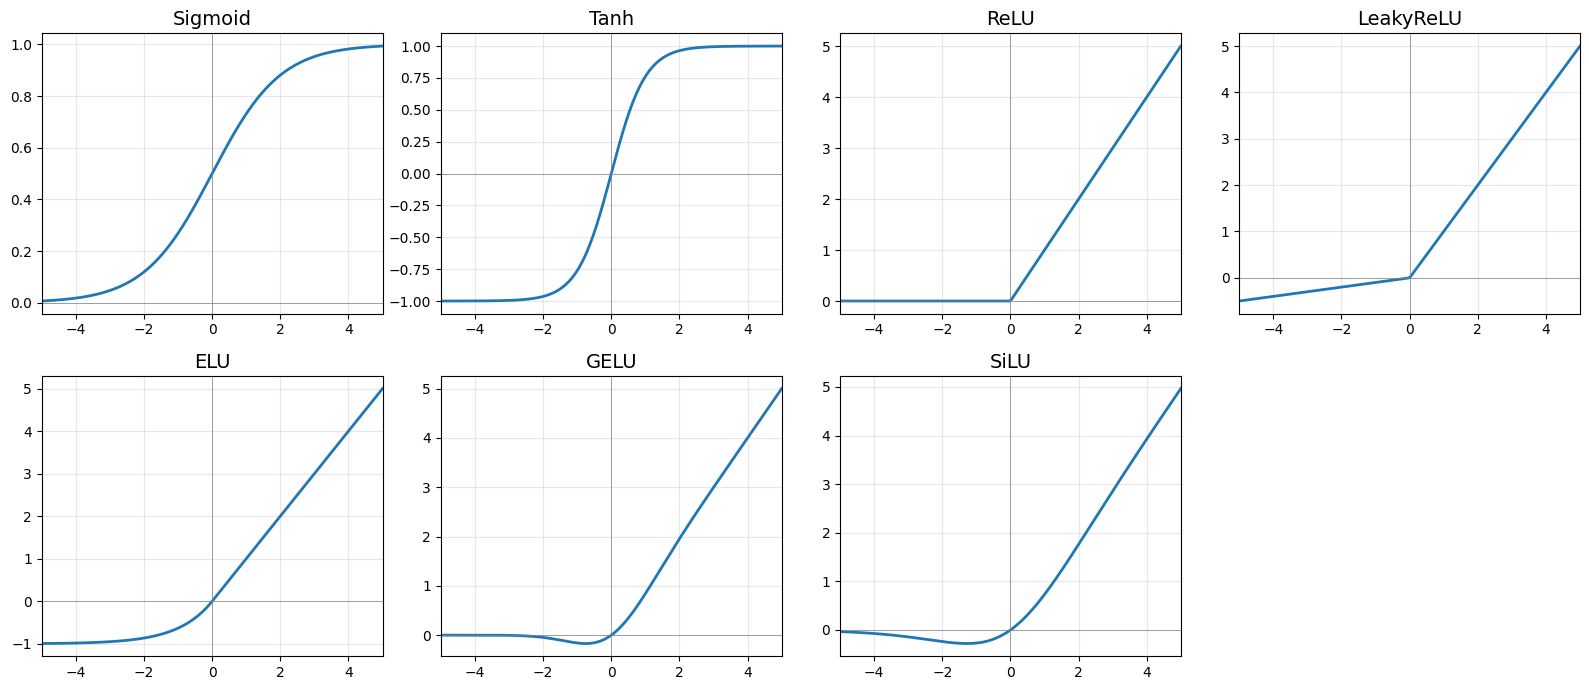

In [10]:
# Let's visualize the four main activation functions
x = torch.linspace(-5, 5, 200)

activations = {
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(negative_slope=0.1),
    'ELU': nn.ELU(alpha=1.0),
    'GELU': nn.GELU(),
    'SiLU': nn.SiLU()
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for ax, (name, func) in zip(axes, activations.items()):
    y = func(x)
    ax.plot(x.numpy(), y.detach().numpy(), linewidth=2)
    ax.set_title(name, fontsize=14)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

# Hide any unused subplot(s) completely (for 7 activations, this is the last box)
for ax in axes[len(activations):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### When to Use Each Activation

| Activation | Range | Best For | Watch Out |
|-----------|-------|----------|-----------|
| **Sigmoid** | $(0, 1)$ | Binary classification output | Vanishing gradients; outputs saturate near 0 and 1 |
| **Tanh** | $(-1, 1)$ | Hidden layers (centered output) | Same vanishing gradient issue as sigmoid |
| **ReLU** | $[0, \infty)$ | Hidden layers (default choice) | "Dead neurons" — if a neuron always outputs 0, it stops learning |
| **LeakyReLU** | $(-\infty, \infty)$ | Hidden layers (fixes dead ReLU) | Small negative slope, so fixes the "dead neuron" problem |
| **ELU**  | $(-\alpha, \infty)$ | Hidden layers; smoother than ReLU and allows negative outputs | Slightly slower than ReLU; can saturate on large negative inputs |
| **GELU** | $\approx(-0.17, \infty)$ | Hidden layers in modern deep nets (especially Transformers) | More computationally expensive; often overkill for small/simple models |
| **SiLU** | $\approx(-0.28, \infty)$ | Hidden layers; smooth ReLU-like behavior, often strong empirical performance | More compute than ReLU; gains are task-dependent |

**Practical rule of thumb**: Start with **ReLU** for most hidden layers (especially tabular MLPs). If you see dead-neuron behavior, try **LeakyReLU** or **ELU**. For deeper modern architectures, **SiLU** or **GELU** are strong alternatives. Use **Sigmoid** for binary classification outputs, **no output activation** with `CrossEntropyLoss` for multi-class classification, and **no activation (linear output)** for regression.


### Using Activations in PyTorch

There are two ways to use activation functions:

1. **As a module** (defined in `__init__`, used in `forward`) — what we've been doing
2. **As a function** from `torch.nn.functional` — called directly in `forward`

Both produce identical results. The module approach is slightly more explicit; the functional approach is more concise:

In [11]:
import torch.nn.functional as F

class ModuleStyle(nn.Module):
    """Using activation as a module (stored in __init__)"""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 8)
        self.relu = nn.ReLU()        # Activation as a module
    
    def forward(self, x):
        x = self.linear(x)
        x = self.relu(x)             # Use the stored module
        return x


class FunctionalStyle(nn.Module):
    """Using activation as a function (called in forward)"""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 8)
        # No activation defined here
    
    def forward(self, x):
        x = self.linear(x)
        x = F.relu(x)                # Call function directly
        return x

# Both produce the same architecture
print("Module style:", ModuleStyle())
print("\nFunctional style:", FunctionalStyle())

Module style: ModuleStyle(
  (linear): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
)

Functional style: FunctionalStyle(
  (linear): Linear(in_features=4, out_features=8, bias=True)
)


Which style should you use? It mostly comes down to preference and readability. The module style makes all components visible when you print the model. The functional style is more concise. You'll see both in practice.

## Dropout: Regularization by Random Silence

<img alt="Neo gets silenced in the matrix" src="../images/L10_neo_silenced.png" width= 900 style="display:block;">
<font size=2>Neo gets silenced by Agent Smith in <i>The Matrix (1999)</i></font>

**Dropout** is one of the most important regularization techniques in deep learning. During training, it randomly sets a fraction of inputs to zero at each forward pass. In other words, <font color="blue">dropout randomly "silences" neurons during training</font>, forcing the network to not rely too heavily on any single neuron or pathway.

The key idea: if any neuron could be dropped at any time, the network must learn **redundant representations** — multiple ways to arrive at the right answer. This makes the model more robust and reduces overfitting.

In [12]:
# Dropout randomly zeros out elements
dropout = nn.Dropout(p=0.5)  # 50% chance each element is zeroed

x = torch.ones(1, 10)  # All ones for easy visualization
print(f"Input:  {x}")

# In training mode, dropout is active
dropout.train()  # This is the default mode
print(f"After dropout (training): {dropout(x)}")
print(f"After dropout (training): {dropout(x)}")  # Different each time!

# In eval mode, dropout is disabled — all values pass through
dropout.eval()
print(f"After dropout (eval):     {dropout(x)}")

Input:  tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
After dropout (training): tensor([[0., 0., 0., 2., 2., 2., 2., 0., 2., 2.]])
After dropout (training): tensor([[0., 0., 2., 2., 2., 0., 0., 2., 0., 2.]])
After dropout (eval):     tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


Notice something important: the surviving values are **scaled up** by $\frac{1}{1-p}$. With `p=0.5`, surviving values are multiplied by 2. This ensures the expected sum stays the same whether dropout is on or off. This is called **inverted dropout** and it's why we can simply turn dropout off during inference without changing anything else.

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
   ⚠️ 
  </span>

**Warning**: You must switch between `.train()` and `.eval()` modes when training and evaluating! If you forget to call `model.eval()` before inference, dropout will still be active, and your predictions will be noisy and wrong. It's not just dropout, there are many other layers that behave differently during training vs evaluation mode.

  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Batch Normalization

<img alt="Hoeny I shrunk the kids" src="../images/L10_honeyIshrunk_normalized.png" width=900 style="display:block;">
<font size=2>The kids get "batch normalized" in <i>Honey, I shrunk the kids (1989)</i></font>

**Batch normalization** is another powerful technique that normalizes the inputs to each layer so they have zero mean and unit variance (computed across the batch). This helps with:

- **Faster training** — gradients flow more smoothly
- **Stability** — less sensitive to learning rate and initialization
- **Slight regularization** — the noise from batch statistics acts as a regularizer

It's called "batch" normalization because the mean and variance are computed over each mini-batch during training.

In [13]:
# BatchNorm1d for fully connected layers (normalizes over the batch dimension)
bn = nn.BatchNorm1d(num_features=8)

# Create a batch of data with non-zero mean and large variance
x = torch.randn(32, 8) * 5 + 10  # mean ≈ 10, std ≈ 5

print(f"Before BatchNorm: mean = {x.mean(dim=0).mean():.2f}, std = {x.std(dim=0).mean():.2f}")

bn.train()
y = bn(x)
print(f"After BatchNorm:  mean = {y.mean(dim=0).mean():.2f}, std = {y.std(dim=0).mean():.2f}")

Before BatchNorm: mean = 9.31, std = 5.05
After BatchNorm:  mean = -0.00, std = 1.02


Like dropout, batch normalization behaves differently in training vs evaluation mode:
- **Training mode**: Uses batch statistics (mean/variance of current batch)
- **Eval mode**: Uses *running averages* of statistics accumulated during training

This means the model's behavior is consistent at inference time, regardless of batch size.

<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    🛠️
  </span>

**BatchNorm** relies on mini-batch statistics and gathers long-term running averages for use in eval mode, which makes it susceptible to instability for out-of-domain inference. There are alternatives. **LayerNorm** (common in Transformers) normalizes across features within each individual sample, while **GroupNorm** (common in vision models) normalizes within channel groups.

  
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Putting Components Together: The Standard Recipe

A common pattern for a fully connected block is:

**Linear → BatchNorm → Activation → Dropout**

This ordering is a convention backed by practice. Let's build a helper that creates this block:

In [14]:
def make_fc_block(in_features, out_features, dropout_rate=0.3):
    """Creates a standard fully connected block: Linear -> BatchNorm -> ReLU -> Dropout"""
    return nn.Sequential(
        nn.Linear(in_features, out_features),
        nn.BatchNorm1d(out_features),
        nn.ReLU(),
        nn.Dropout(dropout_rate)
    )

# Example: a block that goes from 64 features to 32
block = make_fc_block(64, 32, dropout_rate=0.3)
print(block)

# Pass data through
x = torch.randn(16, 64)  # Batch of 16 samples, 64 features
y = block(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {y.shape}")

Sequential(
  (0): Linear(in_features=64, out_features=32, bias=True)
  (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
)

Input shape:  torch.Size([16, 64])
Output shape: torch.Size([16, 32])


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  **The ordering debate**: You'll see people argue about whether BatchNorm should come before or after activation, or whether dropout should come before or after activation. In practice, the differences are small. The ordering shown here (Linear → BatchNorm → ReLU → Dropout) is a solid default.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

<!-- Start Exercise 10.2 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 10.2: Observe Dropout's Train vs. Eval Mode Behavior </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Dropout behaves very differently depending on whether the model is in training or evaluation mode — understanding this is critical for using models correctly.

Build a small model using the `make_fc_block` helper:
1. Use `make_fc_block(10, 32, dropout_rate=0.5)` as the hidden block (high dropout so the effect is obvious)
2. Add an output layer `nn.Linear(32, 1)` with no dropout
3. Wrap both in `nn.Sequential`

Then run the following experiments using a **fixed input** `x = torch.ones(4, 10)` (all ones so any changes are easy to see):

1. Put the model in **training mode** (`model.train()`). Run `model(x)` twice and print both outputs. Are the results the same?
2. Put the model in **evaluation mode** (`model.eval()`). Run `model(x)` twice and print both outputs. Are the results the same now?

**Bonus**: You may notice that the values in eval mode differ from those seen in training mode, even when the same neurons "survive". Can you explain why? *(Hint: think about what inverted dropout does to surviving activations — what does it multiply them by, and does that scaling apply in eval mode?)*

</div>

In [1]:
# Exercise 10.2: Observe Dropout's Train vs. Eval Mode Behavior

# Add code so everything is self-contained in this exercise cell
# Imports
import torch
import torch.nn as nn


# Define make_fc_block again here for convenience
def make_fc_block(in_features, out_features, dropout_rate=0.5):
    """Creates a standard fully connected block: Linear -> BatchNorm -> ReLU -> Dropout"""
    return nn.Sequential(
        nn.Linear(in_features, out_features),
        nn.BatchNorm1d(out_features),
        nn.ReLU(),
        nn.Dropout(dropout_rate)
    )



# 1. Build the model using make_fc_block and nn.Sequential
# YOUR CODE HERE
model = nn.Sequential(
    make_fc_block(10, 32, dropout_rate=0.5),
    nn.Linear(32, 1),
)

# 2. Create a fixed input (all ones, so any changes are easy to spot)
# YOUR CODE HERE
x = torch.ones(4, 10)

# 3. Training mode: run two forward passes and print both outputs
# YOUR CODE HERE
model.train()
print(model(x))
print(model(x))

# 4. Eval mode: run two forward passes and print both outputs
# YOUR CODE HERE
model.eval()
print(model(x))
print(model(x))




tensor([[-0.0202],
        [-0.0202],
        [-0.0202],
        [-0.0202]], grad_fn=<AddmmBackward0>)
tensor([[-0.0202],
        [-0.0202],
        [-0.0202],
        [-0.0202]], grad_fn=<AddmmBackward0>)
tensor([[-0.0825],
        [-0.0825],
        [-0.0825],
        [-0.0825]], grad_fn=<AddmmBackward0>)
tensor([[-0.0825],
        [-0.0825],
        [-0.0825],
        [-0.0825]], grad_fn=<AddmmBackward0>)


<hr/>
<!-- End Exercise 10.2 -->

# 10.3 Building and Training Simple Architectures

<img alt="Alien architecture" src="../images/L10_alien_architecture.png" width=900 style="display:block;">
<font size=2>The crew of the Nostromo investigate alien architecture in <i>Alien (1979)</i></font>

Now let's use everything we've learned to build real, useful network architectures. In later lectures, we'll learn about more advanced architectures. For now, we'll start with the most fundamental: the **Multi-Layer Perceptron (MLP)**.

## Multi-Layer Perceptrons (MLPs)

An MLP is a fully connected feedforward neural network. Data flows in one direction — from input to hidden layers to output — with no loops or skip connections. It's the "vanilla" neural network and still one of the most widely used architectures for tabular data.

Let's build a flexible MLP class:

In [2]:
class MLP(nn.Module):
    """
    A flexible Multi-Layer Perceptron.
    
    Args:
        input_size:   Number of input features
        hidden_sizes: List of hidden layer sizes (e.g., [128, 64, 32])
        output_size:  Number of outputs
        dropout_rate: Dropout probability (0 = no dropout)
        use_batchnorm: Whether to include batch normalization
    """
    
    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        
        layers = []
        prev_size = input_size  # We'll update this as we iterate through hidden layers so that each layer's input size matches the previous layer's output size
        
        # Build hidden layers
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer (no activation — applied externally or inside loss function)
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers) # Unpack the list of layers as arguments to Sequential
    
    def forward(self, x):
        return self.network(x)

Now let's build an MLP model using the class we just defined:

In [3]:
# Example: a 4-layer MLP for classifying data that has 17 features and 5 classes, with dropout and batch normalization
model = MLP(
    input_size=17,              # 17 features
    hidden_sizes=[64, 32, 16],  # Three hidden layers
    output_size=5,              # 5 classes
    dropout_rate=0.2,
    use_batchnorm=True
)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=5, bias=True)
  )
)

Total parameters: 4,069



This MLP class is versatile! By changing the arguments, you can create networks of any depth and width. Let's imagine we are trying to train an MLP to be a binary classifier for input data that has 10 features. Note that our MLP just gives us a raw score as output; we'd have to translate that score into a class label (typically we'd apply a sigmoid so that we can interpret this score as a probability). Let's see a few configurations that fit this problem:

In [23]:
# A tiny network — fast but limited capacity
tiny = MLP(input_size=10, hidden_sizes=[16], output_size=1)
print(f"Tiny:   {sum(p.numel() for p in tiny.parameters()):>6,} params")

# A medium network — good default
medium = MLP(input_size=10, hidden_sizes=[64, 32], output_size=1)
print(f"Medium: {sum(p.numel() for p in medium.parameters()):>6,} params")

# A larger network — more capacity, more overfitting risk
large = MLP(input_size=10, hidden_sizes=[256, 128, 64], output_size=1)
print(f"Large:  {sum(p.numel() for p in large.parameters()):>6,} params")

# A deep, narrow network
deep = MLP(input_size=10, hidden_sizes=[32, 32, 32, 32, 32], output_size=1)
print(f"Deep:   {sum(p.numel() for p in deep.parameters()):>6,} params")

Tiny:      193 params
Medium:  2,817 params
Large:  44,033 params
Deep:    4,609 params


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>

  **Width vs Depth**: A common question is whether to make networks wider (more neurons per layer) or deeper (more layers). In general, deeper networks can learn more complex hierarchical features, while wider networks have more capacity per layer. For tabular data, a few layers with moderate width (e.g., `[128, 64, 32]`) is usually a good starting point. Very deep networks (10+ layers) are more common for images and text.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

## Demo: Training an MLP on Wine Quality Data

<img alt="Princess Bride and the goblet game" src="../images/L10_princessbride_wine.png" width=900 style="display:block;">
<font size=2>Vizzini debates which wine to drink in <i>The Princess Bride (1987)</i></font>

Let's put our MLP to work on a real dataset. We'll use the Wine Quality dataset — a classic ML dataset where we predict wine quality (a score from 0–10) based on chemical properties like acidity, sugar content, and alcohol level.


We'll start by loading the data and looking at it:

In [24]:
# Load the wine quality dataset
wine_df = pd.read_csv('../data/winequality-red.csv', sep=';')
print(f"Dataset shape: {wine_df.shape}")
print(f"\nColumns: {list(wine_df.columns)}")
print(f"\nQuality distribution:\n{wine_df['quality'].value_counts().sort_index()}")
wine_df.head()

Dataset shape: (1599, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Let's grab the **features** and the **targets** (quality) from this dataframe as NumPy arrays.  You can see that the scale of the features varies quite a bit, so we'll want to normalize it (so it has zero mean and unit standard deviation).

In [25]:
# Prepare data for PyTorch
features = wine_df.drop('quality', axis=1).values.astype(np.float32)
targets = wine_df['quality'].values.astype(np.float32)

# Normalize features to zero mean and unit variance (important for neural networks!)
feature_means = features.mean(axis=0)
feature_stds = features.std(axis=0)
features = (features - feature_means) / feature_stds

print(f"Features shape: {features.shape}")
print(f"Targets shape:  {targets.shape}")
print(f"Feature means after normalization: {features.mean(axis=0).round(4)}")

Features shape: (1599, 11)
Targets shape:  (1599,)
Feature means after normalization: [-0. -0.  0.  0. -0. -0.  0. -0. -0. -0. -0.]


Now we can turn make a `Dataset`, split it into train/test/validation, and make train/validation dataloaders:

In [26]:
# Create a PyTorch Dataset
class WineDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features)
        self.targets = torch.tensor(targets).unsqueeze(1)  # (N,) -> (N, 1)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Create dataset and split
dataset = WineDataset(features, targets)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples:   1279
Validation samples: 320


Now we can create our MLP for our 11 input features and 1 output (quality). We'll add a couple of hidden layers and use batchnorm and dropout. We'll also need to pick a loss function (MSE is appropriate here, since we're basically doing a fancier "regression") and an optimizer (we'll use Adam, which is a simple nice default).

In [27]:
# Build our MLP model
wine_model = MLP(
    input_size=11,
    hidden_sizes=[64, 32],
    output_size=1,
    dropout_rate=0.2,
    use_batchnorm=True
)

# Set up training components
loss_fn = nn.MSELoss() # Regression -- we're predicting quality score, so MSE is appropriate
optimizer = optim.Adam(wine_model.parameters(), lr=0.001)

print(wine_model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


We're ready to train out model. Below is a bit different from the training loop we discussed earlier, because I have added **per-epoch validation pass** (often used to ensure we aren't overfitting and that the model will generalize well to unseen data). Notice that this involves switching the model each epoch from training mode to evaluation mode. But don't worry, the training never sees the validation data.

In [28]:
# Train the model
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # --- Training ---
    wine_model.train()  # Enable dropout and batch norm training behavior
    epoch_train_loss = 0.0
    
    for features_batch, targets_batch in train_loader:
        optimizer.zero_grad()
        predictions = wine_model(features_batch)
        loss = loss_fn(predictions, targets_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation ---
    wine_model.eval()  # Disable dropout, use running stats for batch norm
    epoch_val_loss = 0.0
    
    with torch.no_grad():  # No gradient computation needed for validation
        for features_batch, targets_batch in val_loader:
            predictions = wine_model(features_batch)
            loss = loss_fn(predictions, targets_batch)
            epoch_val_loss += loss.item()
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch  10/50 | Train Loss: 4.1168 | Val Loss: 3.9342
Epoch  20/50 | Train Loss: 1.0664 | Val Loss: 0.6313
Epoch  30/50 | Train Loss: 1.0211 | Val Loss: 0.5530
Epoch  40/50 | Train Loss: 0.9575 | Val Loss: 0.4943
Epoch  50/50 | Train Loss: 0.8761 | Val Loss: 0.4809


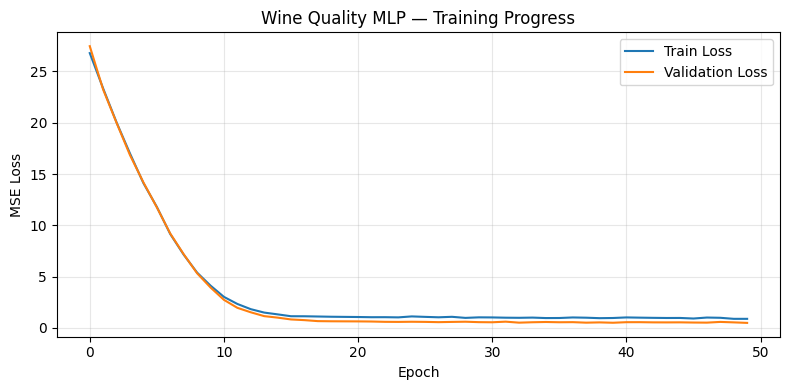

In [29]:
# Plot the training curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Wine Quality MLP — Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

If you see the validation loss diverging from the training loss (going up while training loss keeps going down), that's a sign of **overfitting** (the model memorizing the training data rather than learning general patterns). We'll cover techniques for handling this (early stopping, more regularization) in depth in the next lecture.

<!-- Start Exercise 10.3 -->
<hr/>
<img src="../images/stop_right_margin.png" align="left">

<font size=3 color="darkred"> Exercise 10.3: Implement a 3-Layer MLP Class for MNIST Digit Classification </font>
<div class="inclass_exercise_body" style="padding-left: 130px; width: 85%; text-align: justify;text-align-last: left;">

Build a custom `nn.Module` class called `DigitClassifier` for classifying MNIST digits (0-9). Your network should have:

1. Three hidden layers with sizes 256, 128, and 64
2. ReLU activation after each hidden layer
3. An output layer with 10 neurons (one per digit class)
4. **No** activation after the output layer (CrossEntropyLoss applies softmax internally)

Tips:
- Don't make a customizable MLP like the class we made above. Instead, **hardcode the layer architecture** exactly as described.
- The input to this network will be flattened MNIST images: 28×28 = 784 features.
- After defining the class, create an instance and print it, then verify the total parameter count.

If you want, since you downloaded the MNIST data already in the past lecture, you can even try training your model.

</div>

In [33]:
# Exercise 10.3: Build a 3-layer MLP for MNIST digit classification

class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Define your layers here
        nn.Linear(784, 256)
        ReLu()
        nn.Linear(256, 128)
        ReLu()
        nn.Linear(128, 64)
        ReLu()
        nn.Linear(64, 16)

          # Replace with your implementation
    
    def forward(self, x):
        # Define forward pass here
        pass  # Replace with your implementation

# Create an instance of the model, print it out to inspect its architecture, then print out the total number of parameters to get a sense of its capacity
# YOUR CODE HERE



# Create the variable dummy_input; a dummy batch of 5 flattened 28x28 images -- i.e, a random normal tensor of shape 5x784
# Then pass it through your model. Print out the input and output shapes to verify it works as expected.
# YOUR CODE HERE

# OPTIONAL: Try training your model on the MNIST dataset (you can use torchvision.datasets.MNIST to load it) and see how well it performs. This is a bit more involved, so feel free to skip if you're short on time!

<hr/>
<!-- End Exercise 10.1 -->

## Comparing Activation Functions in Practice

Let's see how the choice of activation function actually affects training. Let's wrap that training logic above in a function, so that we can reuse it:

In [34]:
def train_model(model, train_loader, val_loader, num_epochs=40, lr=0.001):
    """Train a model and return loss history."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    
    train_hist = []
    val_hist = []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for features_batch, targets_batch in train_loader:
            optimizer.zero_grad()
            pred = model(features_batch)
            loss = loss_fn(pred, targets_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_hist.append(train_loss / len(train_loader))
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for features_batch, targets_batch in val_loader:
                pred = model(features_batch)
                loss = loss_fn(pred, targets_batch)
                val_loss += loss.item()
        val_hist.append(val_loss / len(val_loader))
    
    return train_hist, val_hist

Now we'll train the same architecture with different activations and compare:

In [35]:
# Build models with different activations
class ActivationTestNet(nn.Module):
    def __init__(self, activation_fn):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(11, 64),
            activation_fn,
            nn.Linear(64, 32),
            activation_fn,
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

# NOTE: we create fresh activation instances for each model
models = {
    'ReLU': ActivationTestNet(nn.ReLU()),
    'Sigmoid': ActivationTestNet(nn.Sigmoid()),
    'Tanh': ActivationTestNet(nn.Tanh()),
    'LeakyReLU': ActivationTestNet(nn.LeakyReLU()),
}

# Train each model
results = {}
for name, model in models.items():
    train_hist, val_hist = train_model(model, train_loader, val_loader, num_epochs=40)
    results[name] = {'train': train_hist, 'val': val_hist}
    print(f"{name:12s} | Final val loss: {val_hist[-1]:.4f}")

ReLU         | Final val loss: 0.4272
Sigmoid      | Final val loss: 0.4595
Tanh         | Final val loss: 0.4119
LeakyReLU    | Final val loss: 0.4612


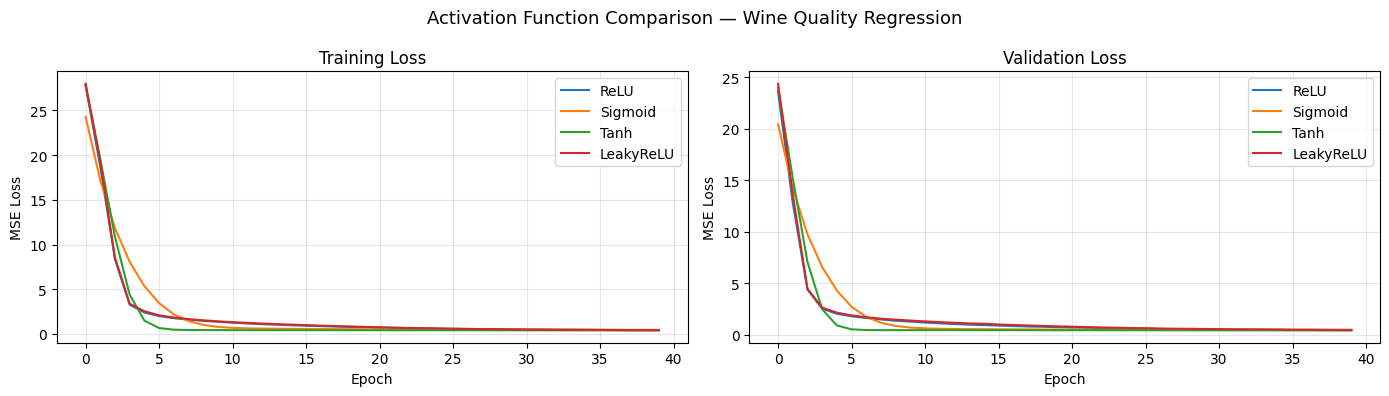

In [36]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, data in results.items():
    # if name in ['ReLU', 'LeakyReLU']:  # Uncomment to plot only specific activations
        axes[0].plot(data['train'], label=name)
        axes[1].plot(data['val'], label=name)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Activation Function Comparison — Wine Quality Regression', fontsize=13)
plt.tight_layout()
plt.show()

You should notice that ReLU and LeakyReLU tend to train faster and reach lower loss for this kind of tabular regression task. Sigmoid often lags behind because of vanishing gradients (the gradients get very small when the sigmoid output is near 0 or 1, slowing down learning).

This is why **ReLU is the default hidden layer activation** for most tasks. Simple, fast, and effective.

## The Effect of Dropout

<img alt="Zed on a bike" src="../images/L10_zed_dropout.png" width=800 style="display:block;">
<font size=2>Zed about to experience the effect of dropout in <i>Police Academy 3: Back in Training (1986)</i></font>

Let's see what dropout actually does to training. We'll compare models with different dropout rates:

In [37]:
# Train models with different dropout rates
dropout_rates = [0.0, 0.1, 0.2, 0.5]
dropout_results = {}

# Create dataset and split
# train_small_size = int(0.1 * len(dataset))
# val_large_size = len(dataset) - train_small_size
# train_dropout_dataset, val_dropout_dataset = random_split(dataset, [train_small_size, val_large_size])

# Create DataLoaders
# train_dropout_loader = DataLoader(train_dropout_dataset, batch_size=64, shuffle=True)
# val_dropout_loader = DataLoader(val_dropout_dataset, batch_size=64, shuffle=False)

for rate in dropout_rates:
    model = MLP(
        input_size=11,
        hidden_sizes=[512, 256, 128, 64],   # Larger network so overfitting is more visible
        output_size=1,
        dropout_rate=rate,
        use_batchnorm=False       # Isolate the effect of dropout
    )
    train_hist, val_hist = train_model(model, train_loader, val_loader, num_epochs=60)
    dropout_results[f'dropout={rate}'] = {'train': train_hist, 'val': val_hist}
    print(f"Dropout {rate:.2f} | Avg last 10 epochs train MSE: {np.mean(train_hist[-10:]):.4f} | Avg last 10 epochs val MSE: {np.mean(val_hist[-10:]):.4f}")

Dropout 0.00 | Avg last 10 epochs train MSE: 0.2006 | Avg last 10 epochs val MSE: 0.3765
Dropout 0.10 | Avg last 10 epochs train MSE: 0.5623 | Avg last 10 epochs val MSE: 0.4081
Dropout 0.20 | Avg last 10 epochs train MSE: 0.7255 | Avg last 10 epochs val MSE: 0.4252
Dropout 0.50 | Avg last 10 epochs train MSE: 1.6325 | Avg last 10 epochs val MSE: 0.5930


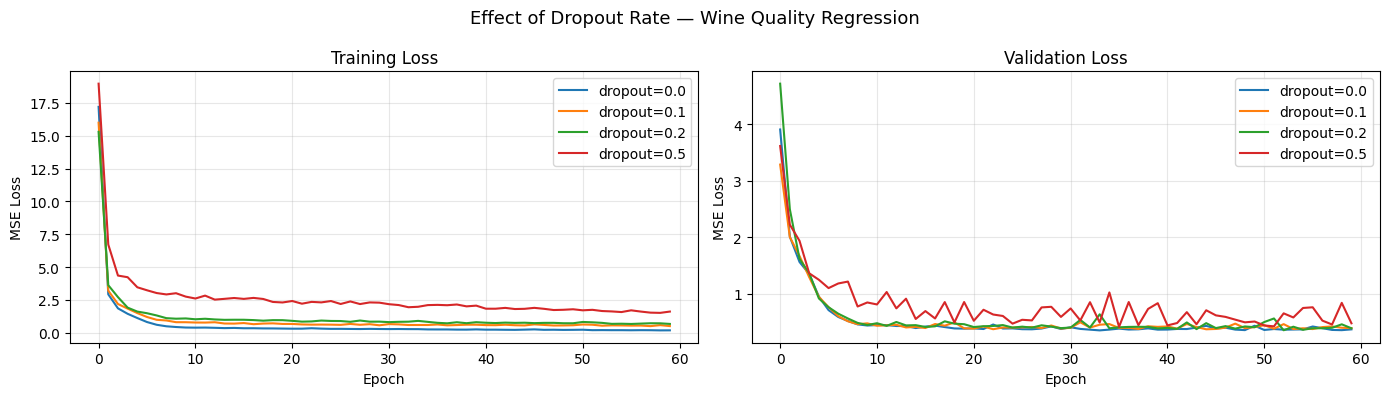

In [38]:
# Plot dropout comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, data in dropout_results.items():
    #if '0.0' in name or '0.1' in name:  # Uncomment to highlight the no-dropout and moderate dropout cases
        axes[0].plot(data['train'], label=name)
        axes[1].plot(data['val'], label=name)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
#axes[1].set_ylim(0.3, 0.6) # Uncomment to zoom in on the lower loss range where differences are more visible
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Effect of Dropout Rate — Wine Quality Regression', fontsize=13)
plt.tight_layout()
plt.show()


What you will typically see:
- **No dropout (0.0)**: Training loss is low, but validation loss may be higher if the network is overfitting (not in this small data example)
- **Moderate dropout (0.1-0.2)**: Good balance — training is slightly slower but validation loss is better
- **High dropout (0.5)**: Training is noticeably harder — the network has to work with less capacity  (though can be useful in fully connected layers in deep NNs)
- **Extreme dropout (0.8)**: Too aggressive — training is very slow and may not converge well

**Sweet spot**: Dropout rates of **0.1–0.3** are typical for fully connected layers. Higher rates (0.4–0.5) are sometimes used in very large networks.


<div class="callout" style="
  width: 80%;
  background: rgba(127,127,127,0.15);
  border: 1px solid rgba(127,127,127,0.3);
  padding: 10px 30px;
  margin: 20px;
  border-radius: 6px;
  text-align: justify;
  text-align-last: left;
  font-size: 11pt;
">
  <span style="
    font-size: 60pt;
    line-height: 1;
    float: left;
    margin: 0px 0px 0px 0;
  ">
    💡
  </span>
  Dropout is a regularizer that we know <b>can</b> be used effectively to improve training and help us avoid overfitting.  But the effect of dropout depends on your data and your model. It can <b>improve validation loss</b> or <b>worsen it</b>. You should experiment with it and see how it affects training.
  <!-- clearfix -->
  <div style="clear: both;"></div>
</div>

# 10.4 Architecture Design Principles

<img alt="The principal principle" src="../images/L10_breakfastclub_principal.png" width=700 style="display:block;">
<font size=2>Principal Vernon must be a Longhorns fan in <i>The Breakfast Club (1985)</i></font>

Now that you have a toolkit of layers, activations, and regularization techniques, how do you decide what architecture to build? Here are some practical guidelines:

## Starting Points by Problem Type

| Problem | Input | Output Layer | Loss Function | Typical Hidden Layers |
|---------|-------|-------------|---------------|----------------------|
| **Binary classification** | Features | 1 neuron + Sigmoid | `BCEWithLogitsLoss` | 2-3 layers, ReLU |
| **Multi-class classification** | Features | N neurons (no activation) | `CrossEntropyLoss` | 2-3 layers, ReLU |
| **Regression** | Features | 1 neuron (no activation) | `MSELoss` | 2-3 layers, ReLU |
| **Image classification** | Images | N neurons (no activation) | `CrossEntropyLoss` | CNNs (upcoming lecture!) |

## Rules of Thumb

1. **Start simple, add complexity only if needed.** A 2-layer MLP is often surprisingly effective. Don't jump to a 10-layer residual network until you've tried the basics.

2. **Funnel shape is usually good.** Start wide, get narrower: `[256 → 128 → 64]` is more common than `[64 → 128 → 256]`. The idea is to progressively compress the representation.

3. **More data allows bigger models.** With 1,000 samples, a small network (few hundred parameters) is fine. With 1,000,000 samples, you can afford millions of parameters.

4. **Regularization is not optional.** For any real task, include at least one of: dropout, batch normalization, weight decay (L2 regularization -- we'll cover this soon). Usually use all three.

5. **Normalize your inputs.** Neural networks train much better when inputs are standardized (zero mean, unit variance). This affects both convergence speed and final performance.

## Common Debugging Tips

When your network isn't learning, here's your debugging checklist:

1. **Loss not decreasing?** 
   - Check that you're calling `optimizer.zero_grad()` before each backward pass
   - Try a higher learning rate
   - Make sure your data is normalized
   - Check that your loss function matches your task (MSELoss for regression, CrossEntropyLoss for classification)

2. **Loss is NaN or Inf?**
   - Lower the learning rate
   - Check for division by zero in your data
   - Add gradient clipping

3. **Training loss is great, validation loss is terrible?**
   - You're overfitting — add dropout, reduce model size, or get more data
   - Make sure you're calling `model.eval()` before validation

4. **Model always predicts the same value?**
   - Check that your targets are correct
   - Try a larger learning rate
   - Make sure the model has enough capacity (layers/neurons)

# Summary

Today we covered how to design and build neural network architectures in PyTorch:

## The `nn.Module` Class
- All PyTorch models extend `nn.Module`
- Define layers in `__init__`, define data flow in `forward`
- Call the model like a function (`model(x)`), not `model.forward(x)`
- Use `nn.Sequential` for simple pipelines, custom `nn.Module` for everything else

## Layer Types and Components
- **Linear layers**: Fully connected transformations (`nn.Linear`)
- **Activation functions**: ReLU (default), Sigmoid (binary output), Tanh, LeakyReLU
- **Dropout**: Randomly zeros neurons during training to prevent overfitting
- **Batch normalization**: Normalizes layer inputs for faster, more stable training

## Building and Training Simple Architectures
- **MLPs**: Stack Linear + Activation + Dropout blocks; funnel shape is common
- **Training Dynamics**: Use validation loss to compare architecture and regularization choices, and to detect overfitting. 
- **Architecture design**: Start simple, add complexity only when needed

## Key Patterns
- Standard block: `Linear → BatchNorm → ReLU → Dropout`
- Always switch between `model.train()` and `model.eval()`
- Normalize your input data before training

In the next lecture, we'll dive deep into **advanced architecture** including embedding layers, skip connections, NN branches. We'll also cover **training/inference best practices**, including more regularization, early stopping, model saving/loading, and deploying trained models.

## Quick Reference Cheat Sheet

| Task | Code |
|------|------|
| Subclass nn.Module | `class MyModel(nn.Module):` |
| Linear layer | `nn.Linear(in_features, out_features)` |
| ReLU activation | `nn.ReLU()` or `F.relu(x)` |
| Sigmoid activation | `nn.Sigmoid()` or `F.sigmoid(x)` |
| Dropout | `nn.Dropout(p=0.3)` |
| Batch normalization | `nn.BatchNorm1d(num_features)` |
| Sequential container | `nn.Sequential(layer1, layer2, ...)` |
| Count parameters | `sum(p.numel() for p in model.parameters())` |
| Training mode | `model.train()` |
| Evaluation mode | `model.eval()` |
| Print architecture | `print(model)` |
| List parameters | `model.named_parameters()` |

# Your Turn: Questions, Reactions, and Feedback

Before our next class, think about:

1. When would you choose a custom `nn.Module` over `nn.Sequential`?
2. How does dropout prevent overfitting? Can you think of an analogy from team dynamics?
3. What architecture would you design for a dataset you've worked with before?
4. How do you decide how many layers and neurons to use?

**Write your thoughts below:**

*[Your reflections here]*